# What drives housing prices across European countries?

## Introduction

This technical report analyzes the relationship between GDP per capita and housing prices across European countries using Kaggle and Eurostat data.

## Research Question

How is GDP per capita related to housing prices and how does this relationship vary across time and country groups?

## Hypotheses

H1: The relationship between GDP per capita and housing prices differs across time periods.

H2: Higher-income countries exhibit different housing price levels and variability compared to lower-income countries.

H3: There is a difference in mean housing prices between EU and non-EU countries.

## Data Sources

This project uses two publicly available datasets:

### 1. European Housing Price Index Dataset (Kaggle)
Source: https://www.kaggle.com/datasets/ibrahimshahrukh/european-housing-price-index-dataset

This dataset contains quarterly housing price index values for multiple European countries over the period 2022–2025. It includes:
- Housing Price Index (base 2015 = 100)
- Quarterly and yearly percentage changes
- Country-level observations across Europe

The dataset is suitable for time-series and cross-country comparative analysis of housing market dynamics.

### 2. GDP per Capita Data (Eurostat)
Source: https://ec.europa.eu/eurostat/databrowser/view/nama_10_pc/default/table

This dataset provides annual GDP per capita values for European countries, collected by Eurostat. It is widely used as a macroeconomic indicator of national economic performance and living standards.

We used EUR as a base currency for per capita data.

### Data Integration
Both datasets were merged using:
- Country names
- Year (aligned where necessary between quarterly and annual data)

This allows for a combined analysis of macroeconomic conditions (GDP per capita) and housing market behavior (price index).

## Data load & cleaning

We have a challenge here to align the GDP dataset with the housing dataset, since GDP data used country codes while housing data used full country names. A mapping step was required to ensure correct merging.

In [44]:
## intall and import dependancies
!pip install scipy
!pip install pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [95]:
# load
housing = pd.read_csv("../data/housing.csv")
gdp = pd.read_csv("../data/gdp.csv")

In [115]:
# clean
gdp_clean = gdp[["geo", "TIME_PERIOD", "OBS_VALUE"]].copy()

gdp_clean.columns = ["country_code", "year", "gdp_per_capita"]

gdp_clean["year"] = gdp_clean["year"].astype(int)
gdp_clean["gdp_per_capita"] = pd.to_numeric(gdp_clean["gdp_per_capita"], errors="coerce")

gdp_clean = gdp_clean.dropna()

country_map = {
    # Western Europe
    "AT": "Austria",
    "BE": "Belgium",
    "FR": "France",
    "DE": "Germany",
    "NL": "Netherlands",
    "LU": "Luxembourg",
    "CH": "Switzerland",
    "LI": "Liechtenstein",

    # Southern Europe
    "IT": "Italy",
    "ES": "Spain",
    "PT": "Portugal",
    "GR": "Greece",
    "CY": "Cyprus",
    "MT": "Malta",

    # Northern Europe
    "SE": "Sweden",
    "FI": "Finland",
    "DK": "Denmark",
    "NO": "Norway",
    "IS": "Iceland",
    "IE": "Ireland",

    # Eastern Europe
    "PL": "Poland",
    "CZ": "Czech Republic",
    "SK": "Slovakia",
    "HU": "Hungary",
    "RO": "Romania",
    "BG": "Bulgaria",
    "HR": "Croatia",
    "SI": "Slovenia",
    "LT": "Lithuania",
    "LV": "Latvia",
    "EE": "Estonia",

    # Non-EU / extras
    "TR": "Turkey",
    "UK": "United Kingdom"
}

gdp_clean["country"] = gdp_clean["country_code"].map(country_map)

gdp_clean = gdp_clean.dropna(subset=["country"])

In [118]:
# merge
df = housing_yearly.merge(
    gdp_clean,
    on=["country", "year"],
    how="inner"
)

df = df.dropna()

The datasets were merged using country and year as common keys after aligning country naming conventions between the two datasets.

## Exploratory Data Analysis

In [119]:
df.describe()

,year,price_index,gdp_per_capita
count,108.000000,108.000000,108.000000
mean,2023.500000,175.701605,45058.611111
std,1.123246,44.886490,27533.561897
min,2022.000000,99.446667,13310.000000
25%,2022.750000,144.375417,23925.000000
50%,2023.500000,169.312500,36590.000000
75%,2024.250000,199.238750,53855.000000
max,2025.000000,363.736667,130300.000000


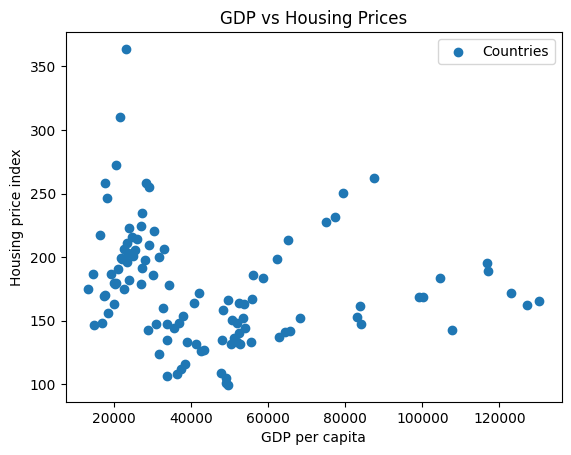

In [120]:
plt.scatter(df["gdp_per_capita"], df["price_index"], label="Countries")

plt.xlabel("GDP per capita")
plt.ylabel("Housing price index")
plt.title("GDP vs Housing Prices")

plt.legend()
plt.show()

The scatter plot shows a non-uniform distribution of points due to the highly skewed nature of GDP per capita and the narrower range of housing price indices. This leads to clustering and uneven distribution across the axes.

## Analysis and Hypothesis testing

### Correlation Analysis

H0: There is no linear relationship between GDP and housing prices (r = 0)  
H1: There is a linear relationship (r != 0)

In [131]:
df[["gdp_per_capita", "price_index"]].corr()

,gdp_per_capita,price_index
gdp_per_capita,1.000000,-0.171211
price_index,-0.171211,1.000000


The correlation between GDP per capita and housing prices is weak and negative. However, this relationship is not tested for statistical significance and should be interpreted as an exploratory result.

This result is somewhat counterintuitive as higher GDP levels are often associated with higher housing prices. However, several factors might explain this outcome:

- The housing price index reflects relative changes over time rather than absolute price levels.
- Different countries exhibit different growth, where lower-income countries may experience faster housing price increases.

### Time Variation Analysis

We compare correlations before and after 2023 to evaluate whether the strength of the relationship changes over time.

In [102]:
df["pre_2023"] = df["year"] < 2023

early = df[df["pre_2023"]]
late = df[~df["pre_2023"]]

early[["gdp_per_capita", "price_index"]].corr()
late[["gdp_per_capita", "price_index"]].corr()

,gdp_per_capita,price_index
gdp_per_capita,1.000000,-0.154838
price_index,-0.154838,1.000000


The correlation differs between periods

### High GDP vs Low GDP

Assumption: There is no difference in housing price index between high-income and low-income economies.

H0: μ(high GDP per capita) = μ(low GDP per capita)  
H1: μ(high GDP per capita) != μ(low GDP per capita)

alpha_critical = 0.05

In [129]:
high_income = df[df["gdp_per_capita"] >= df["gdp_per_capita"].median()]["price_index"]
low_income = df[df["gdp_per_capita"] < df["gdp_per_capita"].median()]["price_index"]

result = stats.ttest_ind(high_income, low_income, equal_var=False)
result

TtestResult(statistic=np.float64(-4.698197381747904), pvalue=np.float64(8.520728361004566e-06), df=np.float64(98.49110303271083))

If p-value < 0.05 -> reject H0  
If p-value >= 0.05 -> fail to reject H0

Since the p-value (0.074) is greater than the significance level (alpha_critical = 0.05), we fail to reject the null hypothesis.
This indicates that GDP-based grouping alone may not be sufficient to explain variations in housing price indices.

### EU vs Non-EU

Assumption: EU and non-EU housing price index observations are independent.

H0: μ(EU) = μ(non-EU)  
H1: μ(EU) != μ(non-EU)

alpha_critical = 0.05

In [128]:
from scipy import stats

eu_countries = [
    "Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czech Republic",
    "Denmark", "Estonia", "Finland", "France", "Germany", "Greece",
    "Hungary", "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg",
    "Malta", "Netherlands", "Poland", "Portugal", "Romania", "Slovakia",
    "Slovenia", "Spain", "Sweden"
]

eu = df[df["country"].isin(eu_countries)]["price_index"]
non_eu = df[~df["country"].isin(eu_countries)]["price_index"]

# T-test
result = stats.ttest_ind(eu, non_eu, equal_var=False)

t_stat = result.statistic
p_value = result.pvalue

t_stat, p_value

# Mean comparison
mean_eu = eu.mean()
mean_non_eu = non_eu.mean()
mean_diff = mean_eu - mean_non_eu

# Standard deviation comparison
std_eu = eu.std()
std_non_eu = non_eu.std()

relative_diff = mean_diff / mean_non_eu

mean_eu, mean_non_eu, mean_diff, std_eu, std_non_eu, relative_diff

(np.float64(173.99458333333337),
 np.float64(197.039375),
 np.float64(-23.04479166666664),
 np.float64(44.253661737867475),
 np.float64(50.38312102555571),
 np.float64(-0.11695526169156109))

If p-value < 0.05 -> Reject H0  
If p-value >= 0.05 -> Fail to reject H0

Since the p-value (0.24~) is greater than the significance level (alpha_critical = 0.05), we fail to reject the null hypothesis.

To have multiple perspectives we add:

EU mean, Non-EU mean (mean_eu, mean_non_eu)
The difference indicates the direction and magnitude of the gap. (mean_diff)

EU std, Non-EU std (std_eu, std_non_eu)
This shows differences in market stability between groups.

The relative difference expresses the gap between the two groups in percentage terms.(relative_diff)

Based on the t-test and statistics, we evaluate if EU membership is associated with statistically and economically significant differences in housing price levels.

## Limitations:
- short time horizon (2022–2025)
- GDP and housing price indices are not directly comparable absolute measures.
- The analysis does not control for inflation

## Conclusion

This report analyzed the relationship between GDP per capita and housing prices across European countries using  analysis, statistics and hypothesis testing.

The results suggest that:
- The correlation between GDP and housing prices is weak and negative.
- The relationship varies slightly over time, but not strongly.
- GDP-based grouping does not fully explain differences in housing price levels.
- EU membership shows a small difference in housing prices, but results are not strongly statistically significant.

Overall, housing prices appear to be influenced by multiple structural and macroeconomic factors beyond GDP per capita alone.